In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_raw = pd.read_csv("D:\\ML&DL\\heart.csv")
data = data_raw.copy()

In [3]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
data.replace({"Age":0 , "RestingBP":0 , "Cholesterol":0 , "MaxHR":0 },np.nan , inplace=True)

In [5]:
data.isna().sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

In [6]:
data_categorical = data.select_dtypes("object")
data_numerical = data.select_dtypes(["float64" , "int64"]).iloc[:,:-1]
y = data.iloc[:,-1].values

In [7]:
from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()

In [8]:
data_categorical = data_categorical.apply(label_enc.fit_transform)

In [9]:
from sklearn.preprocessing import OneHotEncoder
ohe_enc = OneHotEncoder()

In [10]:
data_categorical_bin = data_categorical[["Sex","ExerciseAngina"]]

In [11]:
data_ohe = ohe_enc.fit_transform(data_categorical[["ChestPainType", "RestingECG" , "ST_Slope"]].values).toarray()

In [12]:
data_ohe.shape

(918, 10)

In [13]:
data = np.concatenate([data_numerical.values , data_categorical_bin.values , data_ohe], axis = 1)

In [14]:
pd.DataFrame(data)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,40.0,140.0,289.0,0.0,172.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49.0,160.0,180.0,0.0,156.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37.0,130.0,283.0,0.0,98.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,48.0,138.0,214.0,0.0,108.0,1.5,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,54.0,150.0,195.0,0.0,122.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45.0,110.0,264.0,0.0,132.0,1.2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
914,68.0,144.0,193.0,1.0,141.0,3.4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
915,57.0,130.0,131.0,0.0,115.0,1.2,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
916,57.0,130.0,236.0,0.0,174.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [15]:
from sklearn.impute import KNNImputer

In [16]:
imputer = KNNImputer(n_neighbors=3)

In [17]:
data = imputer.fit_transform(data)

In [20]:

from sklearn.preprocessing import MinMaxScaler

In [21]:
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [22]:
X = data

# SVM Classifier

In [23]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [24]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.3 , random_state=1234)

In [25]:
svm_clf = SVC()
svm_clf.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [26]:
y_predict = svm_clf.predict(X_train)
metrics.accuracy_score(y_predict , y_train)

0.8800623052959502

In [27]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV

In [28]:
svm_clf = SVC()
C=np.arange(1.5,4,0.1)
params = {
    "C" : C
}
cv = ShuffleSplit(n_splits=5 , test_size=0.3 , random_state=1234)
clf = GridSearchCV(svm_clf , param_grid=params , scoring='accuracy' , cv=cv , verbose=1 , return_train_score=True)

In [29]:
clf.fit(X,y)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,SVC()
,param_grid,"{'C': array([1.5, 1....7, 3.8, 3.9])}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,ShuffleSplit(...ain_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,C,2.500000000000001


In [30]:
clf.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_C', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'mean_train_score', 'std_train_score'])

In [31]:
test_score = clf.cv_results_['mean_test_score']
train_score = clf.cv_results_['mean_train_score']

In [32]:
test_score.max()

0.8557971014492753

In [33]:
train_score.max()

0.8987538940809969

In [34]:
arg_max = test_score.argmax()

In [35]:
C[arg_max]

2.500000000000001

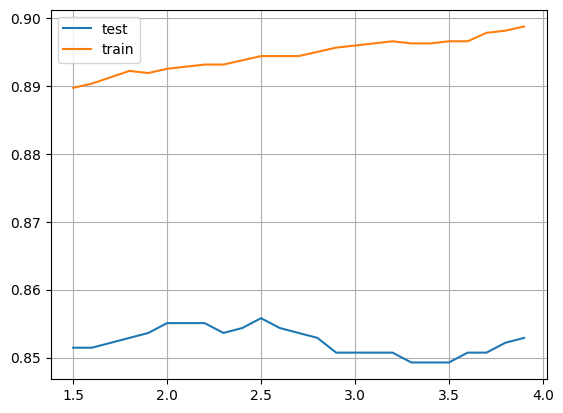

In [36]:
plt.plot(C,test_score,label = 'test')
plt.plot(C,train_score,label= 'train')
plt.legend()
plt.grid(True)

In [37]:
svm_clf= SVC(C = 2.2 , kernel='poly' , degree= 2)
svm_clf.fit(X_train,y_train)

,C,2.2
,kernel,'poly'
,degree,2
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [38]:
svm_clf.score(X_train , y_train)

0.883177570093458

In [39]:
svm_clf.score(X_test , y_test)

0.8731884057971014

In [40]:
svm_clf = SVC()
C=np.arange(1.6,3,0.2)
gamma = np.logspace(-3,3,7)
params = {
    "C" : C,
    "kernel" : ["rbf" , "poly"],
    "gamma" : gamma
}
cv = ShuffleSplit(n_splits=5 , test_size=0.25 , random_state=576)
clf = GridSearchCV(svm_clf , param_grid=params , scoring='accuracy' , cv=cv , verbose=1 , return_train_score=True)

In [41]:
clf.fit(X,y)

Fitting 5 folds for each of 98 candidates, totalling 490 fits


,estimator,SVC()
,param_grid,"{'C': array([1.6, 1....4, 2.6, 2.8]), 'gamma': array([1.e-03...e+02, 1.e+03]), 'kernel': ['rbf', 'poly']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,ShuffleSplit(...ain_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,C,2.5999999999999996


In [42]:
clf.best_score_

0.8730434782608695

In [43]:
clf.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_C', 'param_gamma', 'param_kernel', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'mean_train_score', 'std_train_score'])

In [44]:
test_score = clf.cv_results_['mean_test_score']
train_score = clf.cv_results_['mean_train_score']

In [45]:
clf.score(X_train,y_train)

0.8598130841121495

In [46]:
clf.score(X_test,y_test)

0.8876811594202898

In [47]:
arg_max = test_score.argmax()

In [48]:
clf_params = clf.cv_results_['params']

In [49]:
clf_params[arg_max]

{'C': 2.5999999999999996, 'gamma': 0.01, 'kernel': 'rbf'}

In [50]:
svm = SVC(C=2.59999999999999 ,kernel="rbf" , gamma=0.01)
svm.fit(X_train,y_train)

,C,2.59999999999999
,kernel,'rbf'
,degree,3
,gamma,0.01
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [51]:
svm.score(X_train,y_train)

0.8613707165109035

In [52]:
svm.score(X_test , y_test)

0.8840579710144928